📊 깔끔하게 정돈된 최종 4대장 데이터 테이블:


,Model,Accuracy,Recall,F1_Score
0,Random Forest,0.8771,0.7932,0.8282
1,XGBoost,0.8763,0.8022,0.8284
2,MLP,0.8551,0.7607,0.7963
3,Weighted Voting Ensemble,0.8786,0.8031,0.8312



🎨 버그 수정 완료된 4개 막대 그래프 저장 완료! ➡️ /Users/jmk/bootcamp/project_2/SKN30-2nd-3Team/visualization/model_results/total_model_comparison.png


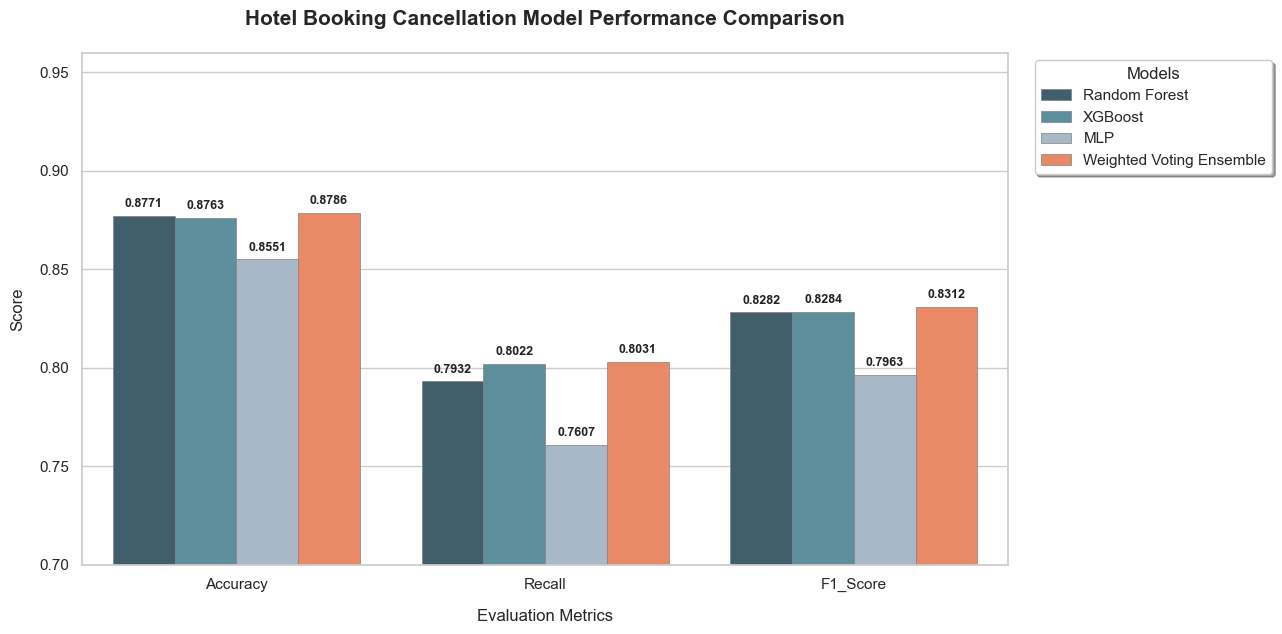

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['axes.unicode_minus'] = False 

# 1. 경로 설정 및 파일 수집
current_dir = os.getcwd()
csv_files = glob.glob(os.path.join(current_dir, '*_result.csv')) + \
            glob.glob(os.path.join(current_dir, 'model_results', '*_result.csv')) + \
            glob.glob(os.path.join(current_dir, '..', 'visualization', 'model_results', '*_result.csv'))

csv_files = list(set(csv_files))

if not csv_files:
    print(f"🚨 Files not found. Please check your csv locations!")
else:
    df_list = []
    for file in csv_files:
        df = pd.read_csv(file)
        if 'Model_Name' in df.columns:
            df = df.rename(columns={'Model_Name': 'Model'})
        df_list.append(df)
    
    df_total = pd.concat(df_list, ignore_index=True)
    
    
    df_total['Model'] = df_total['Model'].replace({
        'MLP (Deep Learning)': 'MLP',
        'final_model': 'Weighted Voting Ensemble'  # 🌟 final_model 매칭 추가
    })
    
    # 중복 행 완전 제거
    df_total = df_total.drop_duplicates(subset=['Model']).reset_index(drop=True)
 
    target_models = ['Random Forest', 'XGBoost', 'MLP', 'Weighted Voting Ensemble']
    df_total = df_total[df_total['Model'].isin(target_models)].copy()
    
    df_total['Model'] = pd.Categorical(df_total['Model'], categories=target_models, ordered=True)
    
    df_total['Model'] = df_total['Model'].cat.remove_unused_categories()
    
    df_total = df_total.sort_values('Model').reset_index(drop=True)
    
    print("📊 깔끔하게 정돈된 최종 4대장 데이터 테이블:")
    display(df_total.round(4))
    
    df_melted = pd.melt(df_total, id_vars='Model', var_name='Metric', value_name='Score')
    
    plt.figure(figsize=(13, 6.5))
    sns.set_theme(style="whitegrid")
    
    # 4대장 전용 컬러 팔레트 
    custom_palette = {
        'Random Forest': '#3A6073',
        'XGBoost': '#5294A5',
        'MLP': '#A3B8CC',
        'Weighted Voting Ensemble': '#FF7F50'  # 앙상블 핵심 오렌지 포인트
    }
    
    # hue_order를 명시하여 빈 공간이 끼어들 틈을 원천 차단합니다.
    ax = sns.barplot(
        x='Metric', 
        y='Score', 
        hue='Model', 
        hue_order=target_models,
        data=df_melted, 
        palette=custom_palette,
        edgecolor='gray',
        linewidth=0.5
    )
    
    # Y축 범위 가독성 조절
    plt.ylim(0.70, 0.96) 
    
    plt.title('Hotel Booking Cancellation Model Performance Comparison', fontsize=15, fontweight='bold', pad=20)
    plt.xlabel('Evaluation Metrics', fontsize=12, labelpad=12)
    plt.ylabel('Score', fontsize=12, labelpad=10)
    
    # 완벽하게 계산된 막대 위 수치 매핑 로직
    for p in ax.patches:
        height = p.get_height()
        if height > 0.70:  # 유효한 스코어만 출력
            ax.text(
                p.get_x() + p.get_width()/2., 
                height + 0.003, 
                f'{height:.4f}', 
                ha="center", 
                va="bottom",
                fontsize=9, 
                fontweight='bold',
                color='#222222'
            )
            
    plt.legend(title='Models', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, shadow=True)
    plt.tight_layout()
    
    save_img_path = os.path.join(current_dir, 'total_model_comparison.png')
    plt.savefig(save_img_path, dpi=300)
    print(f"\n 버그 수정 완료된 4개 막대 그래프 저장 완료! ➡️ {save_img_path}")
    
    plt.show()